<a href="https://colab.research.google.com/github/juniperlovato/Taste_for_Privacy_Facct/blob/main/3_Taste4Privacy_byinst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns

# Data

In [3]:
# read in dataframe
df_all = pd.read_csv('/filepath.csv')

In [4]:
#change colum name 	Unnamed: 0 to ID
df_all = df_all.rename(columns={'Unnamed: 0': 'ID'})

#plot settings

In [6]:
# Visualization helpers

def plot_rank_ci(rank_table: pd.DataFrame, title: str = "Bootstrap ranks: point estimate and 95% CI"):
    # Expect rank_table sorted by Rank ascending
    rt = rank_table.copy().reset_index(drop=True)
    y = np.arange(len(rt))
    x = rt["Rank"].values
    lo = rt["Rank_CI_low"].values
    hi = rt["Rank_CI_high"].values

    fig, ax = plt.subplots(figsize=(6, 0.35*len(rt) + 1.5))
    # error bars: asymmetric by specifying [left, right]
    ax.errorbar(x, y, xerr=[x - lo, hi - x], fmt='o')
    ax.set_yticks(y)
    ax.set_yticklabels(rt["Actor"].values)
    ax.invert_yaxis()
    ax.set_xlabel("Rank (1 = lowest)")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return fig, ax

def plot_rank_violin(boot_ranks: np.ndarray, dominance_table: pd.DataFrame, rank_table: pd.DataFrame,
                     title: str = "Bootstrap rank distributions (violins)"):
    # label order = sorted by point Rank
    order_labels = rank_table["Actor"].tolist()
    # Get original column order from dominance table's columns
    base_labels = dominance_table.columns.tolist()
    # Map to indices
    idx_map = [base_labels.index(lbl) for lbl in order_labels]

    # Reorder boot_ranks columns accordingly
    boot_ord = boot_ranks[:, idx_map]

    fig, ax = plt.subplots(figsize=(8, 0.4*len(order_labels) + 1.5))
    parts = ax.violinplot(boot_ord, vert=False, showmeans=True, showmedians=False, showextrema=False)

    ax.set_yticks(np.arange(1, len(order_labels)+1))
    ax.set_yticklabels(order_labels)
    ax.invert_yaxis()
    ax.set_xlabel("Rank (1 = lowest summary)")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return fig, ax

# Taste for privacy by contexts

In [7]:
Institutions = df_all[['TP_Gov', 'TP_Police',
                      'TP_Friend', 'TP_Relative',
                      'TP_Employer', 'TP_Medical',
                      'TP_Financial', 'TP_Neighbor',
                      'TP_Acquaintance', 'TP_Co_worker',
                      'TP_School', 'TP_Researcher',
                      'TP_Platform', 'TP_NonProf',
                      'TP_Company_cust', 'TP_Company_notcust', 'TP_Stranger' ]]

## Rank institution by likert scores (plots)

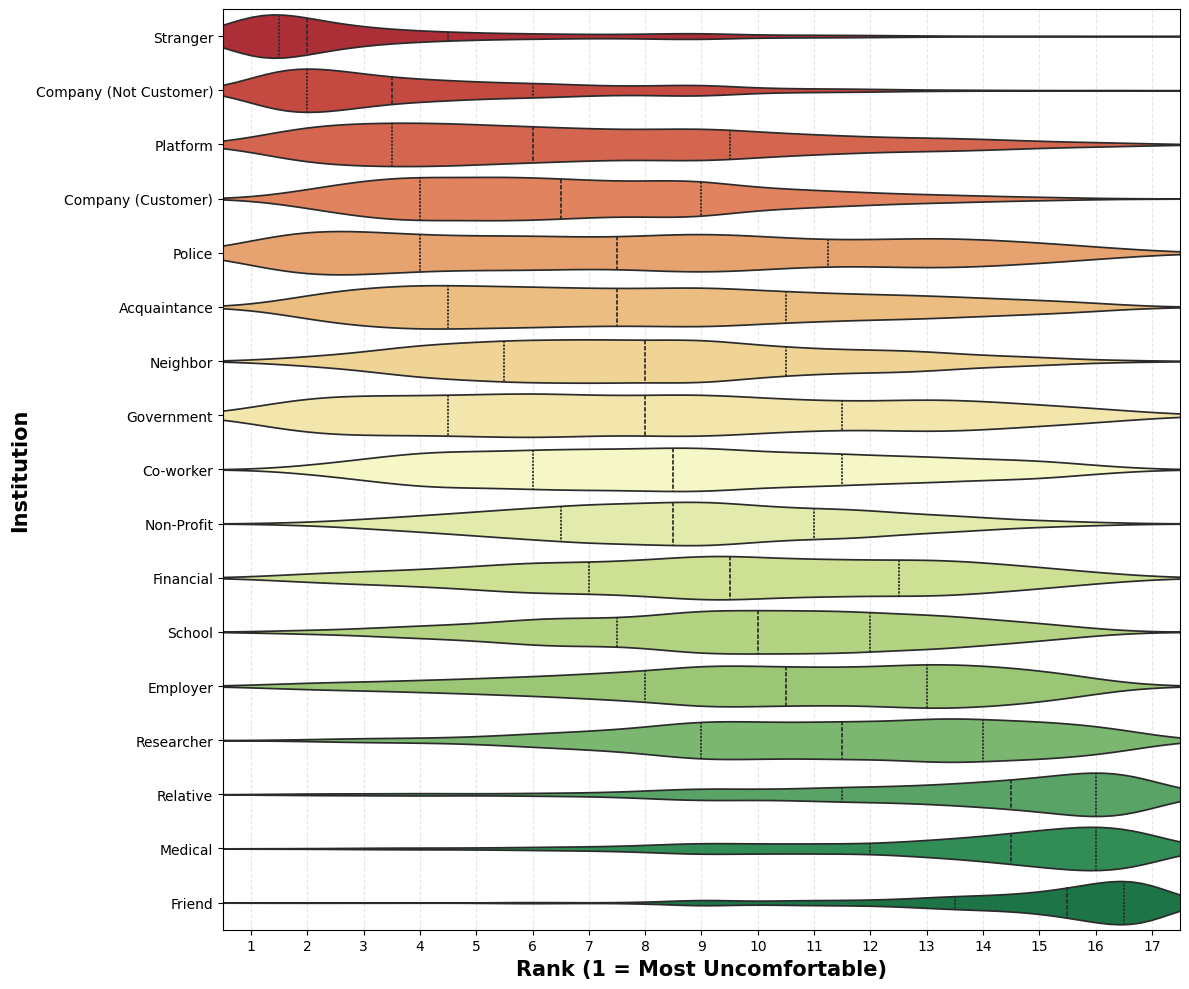

In [11]:
# institution columns and display names
institutions = {
    'TP_Gov': 'Government',
    'TP_Police': 'Police',
    'TP_Friend': 'Friend',
    'TP_Relative': 'Relative',
    'TP_Employer': 'Employer',
    'TP_Medical': 'Medical',
    'TP_Financial': 'Financial',
    'TP_Neighbor': 'Neighbor',
    'TP_Acquaintance': 'Acquaintance',
    'TP_Co_worker': 'Co-worker',
    'TP_School': 'School',
    'TP_Researcher': 'Researcher',
    'TP_Platform': 'Platform',
    'TP_NonProf': 'Non-Profit',
    'TP_Company_cust': 'Company (Customer)',
    'TP_Company_notcust': 'Company (Not Customer)',
    'TP_Stranger': 'Stranger'
}

# Get the columns with values
df_values = df_all[list(institutions.keys())]

# Rank each row (participant) across institutions
# Higher comfort score = higher rank (more uncomfortable institutions get higher ranks)
ranked_df = df_values.rank(axis=1, ascending=False, method='average')

# Renaming columns to display names
ranked_df.columns = [institutions[col] for col in ranked_df.columns]

# Reshaping ranked data to long format
df_long = ranked_df.melt(
    var_name='Institution',
    value_name='Rank'
)

# Calculate mean rank for each institution to order them
institution_mean_rank = df_long.groupby('Institution')['Rank'].mean().sort_values(ascending=True)

# Create the violin plot (horizontal)
fig, ax = plt.subplots(figsize=(12, 10))

sns.violinplot(
    data=df_long,
    y='Institution',
    x='Rank',
    order=institution_mean_rank.index,  # Order by mean rank (lowest/most uncomfortable first)
    inner='quartile',  # Show quartiles
    palette='RdYlGn',  # Red (high discomfort/low rank) to Green (low discomfort/high rank)
    ax=ax
)

# Customize the plot
ax.set_ylabel('Institution', fontsize=15, fontweight='bold')
ax.set_xlabel('Rank (1 = Most Uncomfortable)', fontsize=15, fontweight='bold')

# Set x-axis to show ranks 1-17
ax.set_xlim(0.5, 17.5)
ax.set_xticks(range(1, 18))

# Add grid
ax.xaxis.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()